# <center> Predicting Star Size | Linear Regression
---

<center> <img src = 'https://drive.google.com/uc?id=1Wr3rLlNCBU5qjr1s7o1l-O3DjgLDZIJi' width = 100%>

---

## <center> Linear Regression from Scratch

---
    


## Generating the Data for Linear Regression


In [65]:
# Importing Libraries (numpy and pyplot)
import numpy as np
import matplotlib.pyplot as plt

In [66]:
# Testing --> weigths and bias
# Testing --> Use trained weights and bias to ake predictions

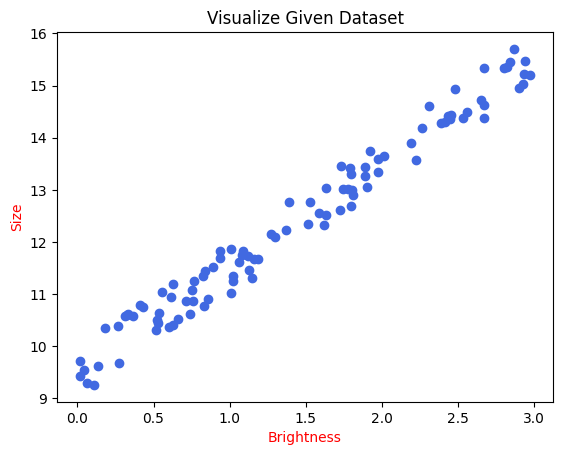

In [67]:
# Use seed value of 100 so that everyone gets the same output!
seed=100
np.random.seed(seed)

# Generating Randomized dataset --> X_train and y_train
'''
X_train = 3*random numbers between 0 and 1 of shape (100, 1)
y_train = 9 + 2*X_train + noise, where noise is a random number between 0 and 1 and its shape is (100, 1)
The noise will allow to have some randomness in output instead of it simply being in a straight line

Our goal of this session is to train ML model --> Linear Regression to predict the values of 9 and 2 in y_train
In reality, we don't have y_train formula. Hence, we make ML model to predict what should be the formula!
'''
x_train=3*np.random.rand(100,1)
y_train=9+2*x_train + np.random.rand(100,1)

# Scatter plot --> Figsize is (8,6), Xlabel is brightness, ylabel is Size, add title
plt.scatter(x_train, y_train,color='royalblue')
plt.xlabel('Brightness',color='red')
plt.ylabel('Size',color='red')
plt.title('Visualize Given Dataset')
plt.show()




In [68]:
# Print first 5 values in X_train and y_train

print(f"here are the first 5 values of x_train:\n {x_train[:5]}")
print(f"here are the first 5 values of y_train:\n {y_train[:5]}")


here are the first 5 values of x_train:
 [[1.63021483]
 [0.83510816]
 [1.27355277]
 [2.5343284 ]
 [0.01415657]]
here are the first 5 values of y_train:
 [[13.03871887]
 [11.44981471]
 [12.1574337 ]
 [14.37765714]
 [ 9.72604804]]


In [69]:
# Check what happens if you remove the noise! --> Remove noise from the y_train and plot again




## Model Parameters and Hyperparameters

Remember that instead of using gradient and y-intercept, we will be using the actual model parameters for ML algorithms - Weight and Bias!

In [70]:
# Initialise the weight (W) and bias (b) to 0
W=1.9
b=9.5

# Hyperparameters --> Choose approproate learning_rate (0.01)
learning_rate=0.01


<img src = "https://drive.google.com/uc?id=1mFaXv4XF-_b-jyP_MK2vfgYfB2dVd4RZ">

## Computing equations for the forward propagation

In [71]:
# Create a function for Predicted Output
def predict(X, W, b):
    '''
    X - full array data
    W - Weight
    b - Bias
    y-full y_train array

    Returns - Predicted output
    '''
    return X*W+b
# MSE cost function
def cost_function(X, y, W, b):
    '''
    y - target values / true values
    Returns - MSE
    '''
    y_pred=predict(x_train,W,b)
    squared_error = (y - y_pred)**2
    MSE = np.mean(squared_error)
    return MSE

cost_function(x_train, y_train, W, b)

0.11326983603486086

<img src = 'https://drive.google.com/uc?id=1ZlXFrHr4ix4w2ND9e1QMZqaMuplh-PTh'>

## Computing equations for the backpropagation


In [72]:
from logging import error
def update_params(X, y, W, b, learning_rate):
    '''
    This function computes all the equations needed for the backpropagation in Linear Regression
    learning rate - alpha=step size
    '''
    error_term = y - predict(X, W, b)
    dJdW = np.mean(-2*X*(error_term))
    dJdb = np.mean(-2*error_term)
    W = W - learning_rate*dJdW
    b = b - learning_rate*dJdb
    return W, b
update_params(x_train, y_train, W, b, learning_rate)

(1.9057994964696667, 9.503218499861498)

In [73]:
# Epoch by epoch train the linear regression to get the best value for W and b
def train(X, y, W, b, learning_rate, tol=1e-13, verbose=False):
    '''
    This function trains the linear regression epoch by epoch
    tol - Threshold for when the training should stop based on convergence
    verbose - Display the training if it is set to True
    '''
    costs = []
    weights = [W]
    biases = [b]
    i=0
    while True:
        i+=1
        W, b = update_params(X, y, W, b, learning_rate)
        weights.append(W)
        biases.append(b)
        cost = cost_function(X, y, W, b)
        costs.append(cost)
        if verbose:
            print(f'Weight: {W},Baises: {b},Epoch: {i}, Cost: {cost}')
        if (len(costs) > 1 and abs(costs[-1] - costs[-2]) < tol):
           break
    return weights, biases, costs, i



In [74]:
# Train the linear regression model
weights, biases, costs, epochs = train(x_train, y_train, W, b, learning_rate, verbose=True)

Weight: 1.9057994964696667,Baises: 9.503218499861498,Epoch: 1, Cost: 0.10902667260125413
Weight: 1.9111875201449335,Baises: 9.506208260353308,Epoch: 2, Cost: 0.10536447593514082
Weight: 1.9161932759016458,Baises: 9.50898551822785,Epoch: 3, Cost: 0.10220370100592917
Weight: 1.9208438957107756,Baises: 9.511565357777686,Epoch: 4, Cost: 0.09947569396038046
Weight: 1.9251645857693471,Baises: 9.513961792635,Epoch: 5, Cost: 0.09712120092016033
Weight: 1.9291787631882813,Baises: 9.51618784176511,Epoch: 6, Cost: 0.095089080952425
Weight: 1.9329081829783916,Baises: 9.518255600066091,Epoch: 7, Cost: 0.09333519525840395
Weight: 1.9363730560231502,Baises: 9.520176303957378,Epoch: 8, Cost: 0.09182144845248708
Weight: 1.9395921586779654,Baises: 9.521960392313007,Epoch: 9, Cost: 0.09051496110783623
Weight: 1.9425829345903072,Baises: 9.523617563069928,Epoch: 10, Cost: 0.08938735559571732
Weight: 1.9453615892928284,Baises: 9.525156825818362,Epoch: 11, Cost: 0.08841413970656128
Weight: 1.9479431780824428

In [75]:
# Comparing initial and final values
import pandas as pd

initial = [weights[0], biases[0], costs[0]]
final = [weights[-1], biases[-1], costs[-1]]
df = pd.DataFrame(list(zip(initial, final)),
                  columns = ['Initial', 'Final'])
df.index = ['Weight', 'Bias', 'Cost']
df


,Initial,Final
Weight,1.900000,1.982251
Bias,9.500000,9.544368
Cost,0.109027,0.082279


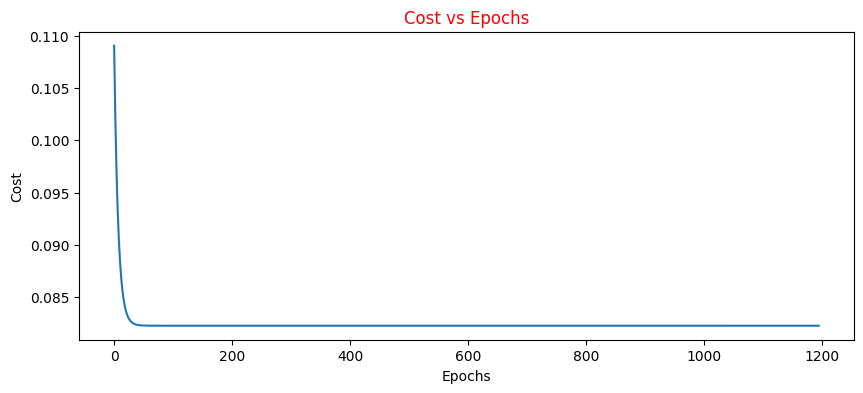

In [83]:
# Visualising the cost wrt epochs --> Figsize is (10,4), plot epochs on x, costs on y, add labels and title
plt.figure(figsize=(10,4))
plt.plot(costs)
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.title('Cost vs Epochs',color='red',)
plt.show()



In [89]:
# Define a seed value (using different seed value compared to trianing set to avoid data leakage!) --> 5007
np.random.seed(789824)  # This number was choose to get the optimal results with random values

# Test data
X_test = 3*np.random.rand(10,1)
y_test = 9 + 2*X_test + np.random.rand(10,1)

prediction = predict(X_test, weights[-1], biases[-1])

# DataFrame to compare true and predicted outputs on test inputs
df1 = pd.DataFrame(list(zip(X_test.reshape(10,), y_test.reshape(10,), prediction.reshape(10,))),
                  columns = ['Test Input', 'True Output', 'Predicted Output'])
df1

,Test Input,True Output,Predicted Output
0,1.941312,13.315135,13.392535
1,2.022859,13.110475,13.554182
2,1.724964,12.984705,12.963681
3,0.911181,11.627978,11.350557
4,1.914371,13.212177,13.339133
5,1.545839,12.739755,12.608609
6,2.319134,14.409829,14.141474
7,1.806776,13.020902,13.125853
8,2.137449,14.112807,13.781330
9,2.239384,13.972726,13.983391


In [91]:
# Calculate the mean sqaured error to evaluate the performance
mse = np.mean((y_test - prediction)**2)
print(f'Mean Squared Error: {round(mse,5)}')


Mean Squared Error: 0.05066


<function matplotlib.pyplot.show(close=None, block=None)>

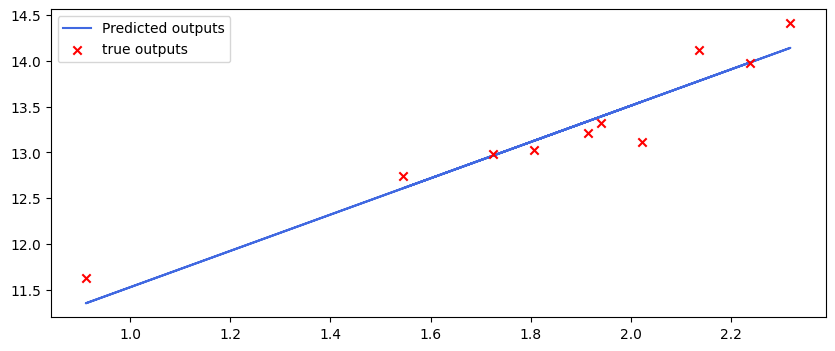

In [99]:
# Visualise the performance of the test data --> (10, 4) figsize, plot(X_test, prediction) and (X_test, y_test)
# Customize it
plt.figure(figsize=(10,4))
plt.plot(X_test,prediction,label='Predicted outputs',color='royalblue')
plt.scatter(X_test, y_test,label='true outputs',marker='x',color='red',zorder=2)
plt.legend()
plt.show



---

# THE END